#### This notebook contains tests to check the running time of the spectral construction algorithms in comparison with EasySpin.
#### The notebook contains draft spin systems and is used for general verification of spectra.

In [68]:
%load_ext autoreload
%autoreload 2

import sys
import os
import typing as tp
import math
from importlib import reload

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Union, Tuple, List
from mars import spin_model, spectra_manager, mesher, constants
import mars

from sample_creators_local import (
                             create_5_electrons_sample, create_2_electrons_2_nuclei_sample,
                             create_1_high_spin_electron_1_nuclei_sample, create_2_middle_spin_sample,
                            create_3_middle_spin_sample, create_heterospin_sample, create_tripletfission_sample, create_heterospin_sample_freq_domain
                            )

from saving_benchmarks import save_benchmark_results, load_benchmark_results

from bencmarking import benchmark_several_configurations, compare_benchmarks, plot_benchmark_comparison, time_spectrum_calculation_full_pipeline, time_spectrum_calculation_full_pipeline_freqdep

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
import matplotlib.pyplot as plt
dtype = torch.float64
device = torch.device("cpu")

### Sample 1.

In [70]:
mesh = mars.mesher.DelaunayMesh(initial_grid_frequency=25, interpolation_grid_frequency=20, interpolator="barycentric", dtype=dtype, interpolate=False)

In [71]:
sample_Mn = create_1_high_spin_electron_1_nuclei_sample(mesh=mesh, device="cpu", dtype=dtype)


freq = 35.0 * 1e9,
field_range = (1.15, 1.325)
n_points = 1000
temperature = 300.0

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-2, res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_Mn,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_Mn, fields=fields)

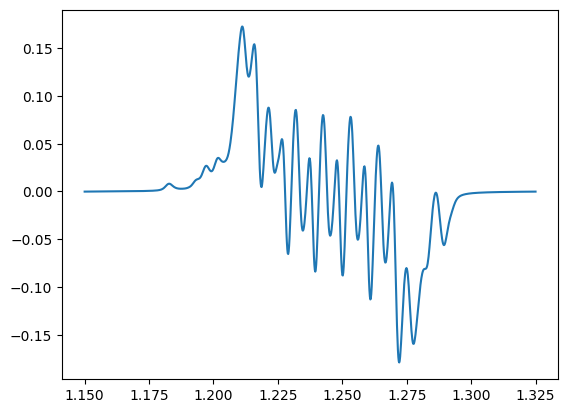

In [55]:
plt.plot(fields, out)

In [139]:
mars.save("easyspin/out_1.mat", sample=sample_Mn, spectra_creator=creator, field=fields, format_type="easyspin")
data_frame = pd.DataFrame({"field": fields, "spec": out})

data_frame.to_csv(f"easyspin/spectrum_1.csv", header=False, index=False)

Check time

In [56]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4)

time_spectrum_calculation_full_pipeline(
    sample_creation_func=create_1_high_spin_electron_1_nuclei_sample,
    sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
    freq=freq, field_range=field_range, n_points=n_points, temperature=temperature,
    computational_details=computational_details,
    n_warmup=2, n_iterations=5,
)

(3554.190320000044,
 519.5411346872614,
 [4588.970800000197,
  3312.967100000151,
  3374.141899999813,
  3242.870400000129,
  3252.0013999999264])

### Sample 2.

In [57]:
mesh = mars.mesher.DelaunayMesh(initial_grid_frequency=25, interpolation_grid_frequency=100, interpolator="rbf", dtype=dtype, interpolate=False)

sample_hetero_spins = create_heterospin_sample(mesh=mesh, device="cpu", dtype=dtype)

freq = 35.0 * 1e9,
field_range = (1.20, 1.29)
n_points = 1000
temperature = 298.0

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-2, res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_hetero_spins,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)
    
out = creator(sample=sample_hetero_spins, fields=fields)

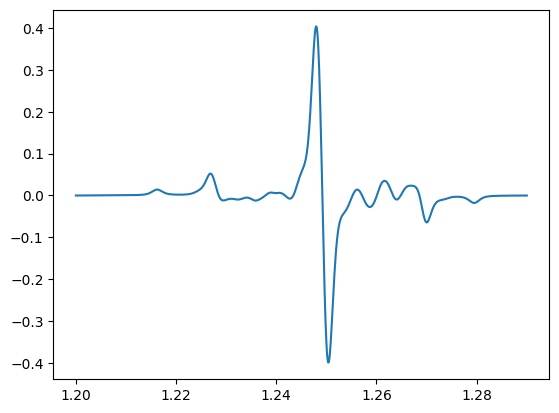

In [58]:
plt.plot(fields, out)

In [123]:
mars.save("easyspin/out_2.mat", sample=sample_hetero_spins, spectra_creator=creator, field=fields, format_type="easyspin")
data_frame = pd.DataFrame({"field": fields, "spec": out})

data_frame.to_csv(f"easyspin/spectrum_2.csv", header=False, index=False)

In [59]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4)

time_spectrum_calculation_full_pipeline(
    sample_creation_func=create_heterospin_sample,
    sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
    freq=freq, field_range=field_range, n_points=n_points, temperature=temperature,
    computational_details=computational_details,
    n_warmup=2, n_iterations=5,
)

(739.881639999976,
 16.445030379978057,
 [770.5752000001667,
  738.4832000000188,
  730.3236999998717,
  737.8237000000354,
  722.2023999997873])

### Sample 3

In [64]:
mesh = mars.mesher.DelaunayMesh(initial_grid_frequency=25, interpolation_grid_frequency=20, interpolator="barycentric", dtype=dtype, interpolate=False)

sample_2_triplets = create_tripletfission_sample(mesh=mesh, device=device, dtype=dtype)

freq = 9.8 * 1e9,
field_range = (0.33, 0.37)
n_points = 1000
temperature = 298.0

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-2, res_field_r_tol=1e-4)

init_populations=[0.0] * 9
init_populations[-3] = 1.0

context = mars.population.Context(sample=sample_2_triplets, init_populations=init_populations, dtype=dtype, device=device)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_2_triplets,
    context=context,
    temperature=temperature,
    computational_details=computational_details,
    harmonic=0,
    device=device,
    dtype=dtype
)
    
out = creator(sample=sample_2_triplets, fields=fields)

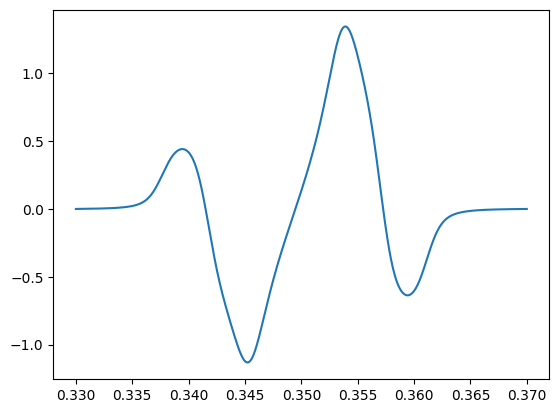

In [65]:
plt.plot(fields, out)

In [67]:
mars.save("easyspin/out_3.mat", sample=sample_2_triplets, spectra_creator=creator, field=fields, format_type="easyspin")
data_frame = pd.DataFrame({"field": fields, "spec": out})

data_frame.to_csv(f"easyspin/spectrum_3.csv", header=False, index=False)

In [63]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4)

time_spectrum_calculation_full_pipeline(
    sample_creation_func=create_tripletfission_sample,
    context=context,
    sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
    freq=freq, field_range=field_range, n_points=n_points, temperature=temperature,
    computational_details=computational_details,
    n_warmup=2, n_iterations=5,
)

(84.10737999997764,
 3.1301253607060757,
 [82.91770000005272,
  88.13599999984945,
  79.49289999987741,
  87.05350000013823,
  82.93679999997039])

### Sample 4

In [47]:
mesh = mars.mesher.DelaunayMesh(initial_grid_frequency=25, interpolation_grid_frequency=20, interpolator="barycentric", dtype=dtype, interpolate=False)

sample_hetero = create_heterospin_sample_freq_domain(mesh=mesh, device=device, dtype=dtype)

n_points = 1000
temperature = 298.0


freq_range = (0.0, constants.unit_converter(25.0, "cm-1_to_Hz"))
freq = torch.linspace(
            freq_range[0],
            freq_range[1],
            n_points,
            device=device,
            dtype=dtype
        )

field = torch.tensor(10.0, device=device, dtype=dtype)

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-3, res_field_r_tol=1e-4)

init_populations=[0.0] * 9
init_populations[-3] = 1.0


intensity_calculator = spectra_manager.WaveIntensityCalculator(
    spin_system_dim=sample_hetero.spin_system_dim,  # spin_system_dim from a sample
    disordered=sample_hetero.mesh.disordered,  # True for powder samples
    polarization='+1',                  # Right-handed (clockwise) circular polarization
    theta=0.0,                  # Propagation perpendicular to static magnetic field
    device=device,
    dtype=dtype,
)

creator = spectra_manager.StationaryFreqSpectra(
    intensity_calculator=intensity_calculator,
    field=field,
    sample=sample_hetero,
    temperature=temperature,
    computational_details=computational_details,
    harmonic=0,
    device=device,
    dtype=dtype
)
    
out = creator(sample=sample_hetero, freq=freq)

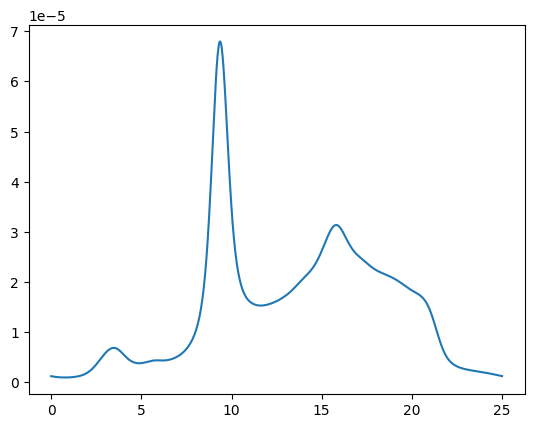

In [48]:
plt.plot(constants.unit_converter(freq, "Hz_to_cm-1"), out)

In [49]:
mars.save("easyspin/out_4.mat", sample=sample_hetero, spectra_creator=creator, field=None, format_type="easyspin")
data_frame = pd.DataFrame({"freq": constants.unit_converter(freq, "Hz_to_cm-1"), "spec": out})

data_frame.to_csv(f"easyspin/spectrum_4.csv", header=False, index=False)

In [50]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4)

intensity_calculator = spectra_manager.WaveIntensityCalculator(
    spin_system_dim=sample_hetero.spin_system_dim,  # spin_system_dim from a sample
    disordered=sample_hetero.mesh.disordered,  # True for powder samples
    polarization='+1',                  # Right-handed (clockwise) circular polarization
    theta=math.pi / 2,                  # Propagation perpendicular to static magnetic field
    device=device,
    dtype=dtype,
)
creator_kwargs = {"intensity_calculator": intensity_calculator}

time_spectrum_calculation_full_pipeline_freqdep(
    sample_creation_func=create_heterospin_sample_freq_domain,
    sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
    field=field, freq_range=freq_range, n_points=n_points, temperature=temperature,
    computational_details=computational_details,
    n_warmup=2, n_iterations=5,
)

(751.214759999948,
 23.99221657448573,
 [734.9174999999377,
  759.2030999999224,
  760.8466000001499,
  785.5894999997872,
  715.5170999999427])

### Sample 3.

In [77]:
sample_5_electrons = create_5_electrons_sample(mesh=mesh, device="cpu", dtype=dtype)


freq = 9.8 * 1e9,
field_range = (0.3, 0.4)
n_points = 1000
temperature = 298.0

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_5_electrons,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_5_electrons, fields=fields)

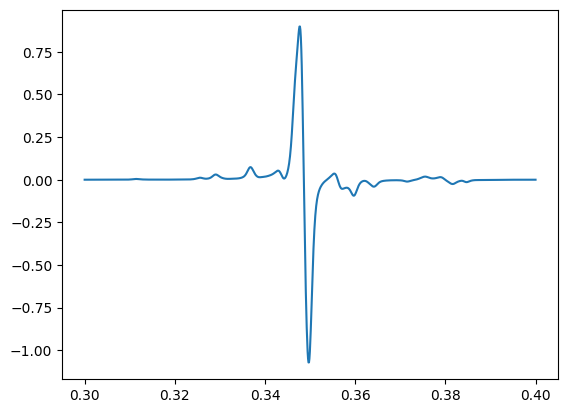

In [78]:
plt.plot(fields, out)

In [79]:
mars.save("easyspin/out_3.mat", sample=sample_5_electrons, spectra_creator=creator, field=fields, format_type="easyspin")
data_frame = pd.DataFrame({"field": fields, "spec": out})

data_frame.to_csv(f"easyspin/spectrum_3.csv", header=False, index=False)

In [80]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4)

time_spectrum_calculation_full_pipeline(
    sample_creation_func=create_5_electrons_sample,
    sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
    freq=freq, field_range=field_range, n_points=n_points, temperature=temperature,
    computational_details=computational_details,
    n_warmup=2, n_iterations=5,
)

(1508.9777400000457,
 46.96743629549132,
 [1431.5095000001747,
  1553.7211000000752,
  1477.7055999998083,
  1540.4070999998112,
  1541.5454000003592])

### Sample 4.

In [72]:
mesh = mars.mesher.DelaunayMesh(initial_grid_frequency=25, interpolation_grid_frequency=20, interpolator="barycentric", dtype=dtype, interpolate=False)

sample_2_el_2_nuc = create_2_electrons_2_nuclei_sample(mesh=mesh, device="cpu", dtype=dtype)

In [73]:
freq = 9.8 * 1e9,
field_range = (0.3444, 0.3550)
n_points = 1000
temperature = 298.0

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_2_el_2_nuc,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_2_el_2_nuc, fields=fields)

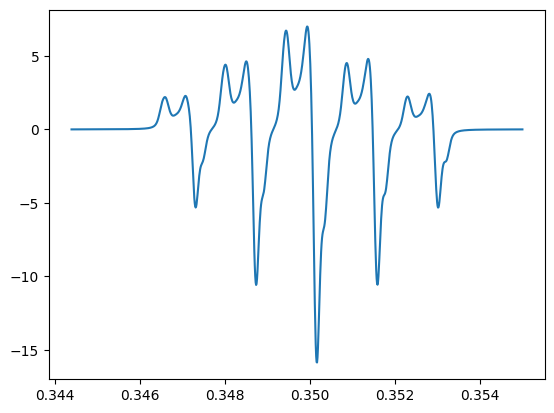

In [74]:
plt.plot(fields, out)

In [75]:
mars.save("easyspin/out_4.mat", sample=sample_2_el_2_nuc, spectra_creator=creator, field=fields, format_type="easyspin")
data_frame = pd.DataFrame({"field": fields, "spec": out})

data_frame.to_csv(f"easyspin/spectrum_4.csv", header=False, index=False)

In [76]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4)

time_spectrum_calculation_full_pipeline(
    sample_creation_func=create_2_electrons_2_nuclei_sample,
    sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
    freq=freq, field_range=field_range, n_points=n_points, temperature=temperature,
    computational_details=computational_details,
    n_warmup=2, n_iterations=5,
)

(1367.7511799998683,
 25.479537387571096,
 [1381.676299999981,
  1349.9084999998558,
  1326.7083999999159,
  1385.8416999996734,
  1394.6209999999155])

#### Plot spectra together

In [408]:
def read_csv(name: str):
    # Read the CSV file - data is in rows, not columns
    df = pd.read_csv(f".\\easyspin\\{name}.csv", header=None)
    
    # First row is 'fields', second row is 'spectrum'
    # Skip the first column (labels) and get the data
    fields = df.iloc[0, 1:].values.astype(float)
    spectrum = df.iloc[1, 1:].values.astype(float)
    
    # Convert to torch tensors
    fields_tensor = torch.tensor(fields, dtype=dtype, device=device)
    spectrum_tensor = torch.tensor(spectrum, dtype=dtype, device=device)
    
    return fields_tensor, spectrum_tensor

#### Sample 1

In [409]:
name = "spec_easy_spin_1"
freq = 35.0 * 1e9,
fields, spectrum_easyspin = read_csv(name)

sample_5_electrons = create_5_electrons_sample(mesh=mesh, device="cpu", dtype=dtype)
creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_Mn,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_Mn, fields=fields)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


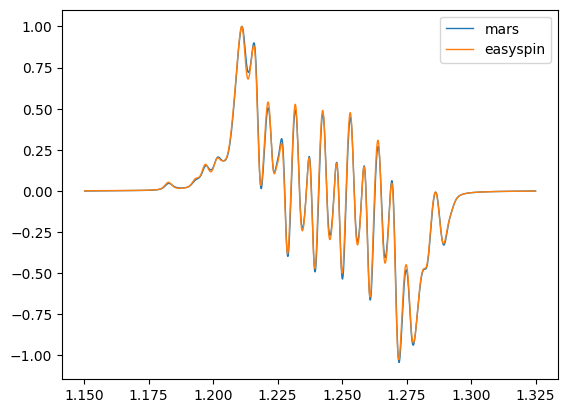

In [414]:
plt.plot(fields, out/ max(out), label="mars", linewidth=1)
plt.plot(fields, spectrum_easyspin / max(spectrum_easyspin), label="easyspin", linewidth=1)
plt.legend()
plt.savefig("example_1.eps")
plt.show()

#### Sample 2

In [427]:
name = "spec_easy_spin_2"
freq = 35.0 * 1e9,
fields, spectrum_easyspin = read_csv(name)

sample_hetero_spins = create_heterospin_sample(mesh=mesh, device="cpu", dtype=dtype)
creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_hetero_spins,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_two_spins, fields=fields)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


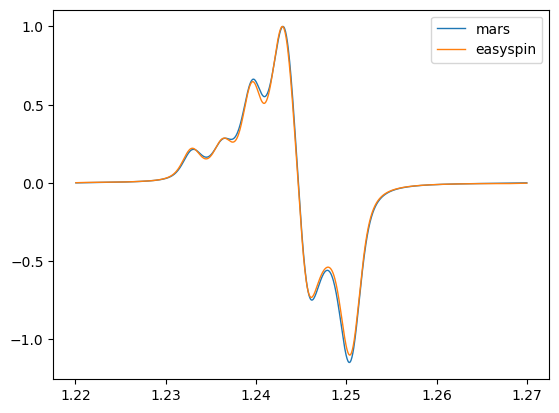

In [428]:
plt.plot(fields, out/ max(out), label="mars", linewidth=1)
plt.plot(fields, spectrum_easyspin / max(spectrum_easyspin), label="easyspin", linewidth=1)
plt.legend()
plt.savefig("example_2.eps")
plt.show()

#### Sample 3

In [421]:
name = "spec_easy_spin_3"
freq = 9.8 * 1e9,
fields, spectrum_easyspin = read_csv(name)

sample_5_electrons = create_5_electrons_sample(mesh=mesh, device="cpu", dtype=dtype)
creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_5_electrons,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_5_electrons, fields=fields)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


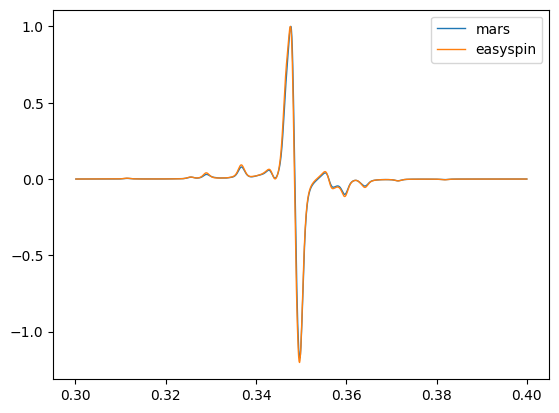

In [422]:
plt.plot(fields, out/ max(out), label="mars", linewidth=1)
plt.plot(fields, spectrum_easyspin / max(spectrum_easyspin), label="easyspin", linewidth=1)
plt.legend()
plt.savefig("example_3.eps")
plt.show()

#### Sample 4

In [425]:
name = "spec_easy_spin_4"
freq = 9.8 * 1e9,
fields, spectrum_easyspin = read_csv(name)

sample_2_el_2_nuc = create_2_electrons_2_nuclei_sample(mesh=mesh, device="cpu", dtype=dtype)
creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_2_el_2_nuc,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_2_el_2_nuc, fields=fields)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


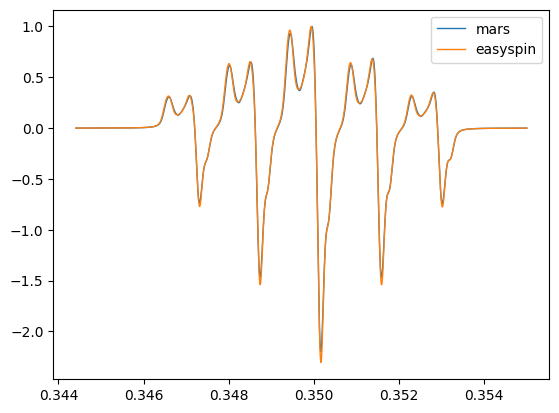

In [426]:
plt.plot(fields, out/ max(out), label="mars", linewidth=1)
plt.plot(fields, spectrum_easyspin / max(spectrum_easyspin), label="easyspin", linewidth=1)
plt.legend()
plt.savefig("example_4.eps")
plt.show()